# E-Commerce Behavioral Analytics: cart abandonment walkthrough

Step-by-step walkthrough of the analysis, using the DuckDB tables built by `src/01_build_tables.py`.
Every number matches the report in `report/` and `outputs/results.json`.

**Data:** client-level sample of the Synerise RecSys Challenge 2025 dataset: 46,673 purchasing users, 9.0M events, 23 Jun – 8 Dec 2022.

**Questions:** how do shoppers move through the store, how big is cart abandonment, what distinguishes heavy abandoners (and does it survive a fair comparison), and what should be built first?

In [1]:
import os, json
from pathlib import Path
if Path.cwd().name == "notebooks":
    os.chdir("..")

import duckdb, numpy as np, pandas as pd
from scipy import stats
from IPython.display import Image, display
pd.set_option("display.precision", 2)
con = duckdb.connect("recsys.duckdb", read_only=True)
q = lambda sql: con.execute(sql).df()
q("SELECT event, COUNT(*) AS events, COUNT(DISTINCT client_id) AS users FROM all_events GROUP BY event ORDER BY events DESC")

,event,events,users
0,visit,6853213,36272
1,search,922717,24305
2,cart_add,635890,34325
3,purchase,335771,46673
4,cart_remove,296719,22628


## 1. Why this isn't a visit → purchase funnel

The sample was drawn from the purchase log, so **every user bought something**. Stage coverage below is therefore about how purchasers get there, not conversion.

In [2]:
q("""
SELECT ROUND(100*AVG((v.client_id IS NOT NULL)::INT),1) AS pct_visited,
       ROUND(100*AVG((s.client_id IS NOT NULL)::INT),1) AS pct_searched,
       ROUND(100*AVG((c.client_id IS NOT NULL)::INT),1) AS pct_carted,
       ROUND(100*AVG((r.client_id IS NOT NULL)::INT),1) AS pct_removed
FROM (SELECT DISTINCT client_id FROM product_buy) u
LEFT JOIN (SELECT DISTINCT client_id FROM page_visit) v USING (client_id)
LEFT JOIN (SELECT DISTINCT client_id FROM search_query) s USING (client_id)
LEFT JOIN (SELECT DISTINCT client_id FROM add_to_cart) c USING (client_id)
LEFT JOIN (SELECT DISTINCT client_id FROM remove_from_cart) r USING (client_id)
""")

,pct_visited,pct_searched,pct_carted,pct_removed
0,77.7,52.1,73.5,48.5


## 2. Journey map: what comes next after each event

In [3]:
tr = q("SELECT event, next_event, pct_of_row FROM transitions")
order = ["visit", "search", "cart_add", "purchase", "cart_remove"]
tr.pivot(index="event", columns="next_event", values="pct_of_row").loc[order, order]

next_event,visit,search,cart_add,purchase,cart_remove
event,,,,,
visit,81.4,9.2,6.8,1.1,1.4
search,75.1,23.0,1.3,0.2,0.4
cart_add,59.0,8.5,21.6,3.2,7.7
purchase,30.5,2.7,1.1,65.2,0.5
cart_remove,35.4,5.2,6.4,4.2,48.9


After a cart-add, the next action is a purchase only **3.2%** of the time; shoppers mostly go back to browsing. Carting is part of the browsing loop.

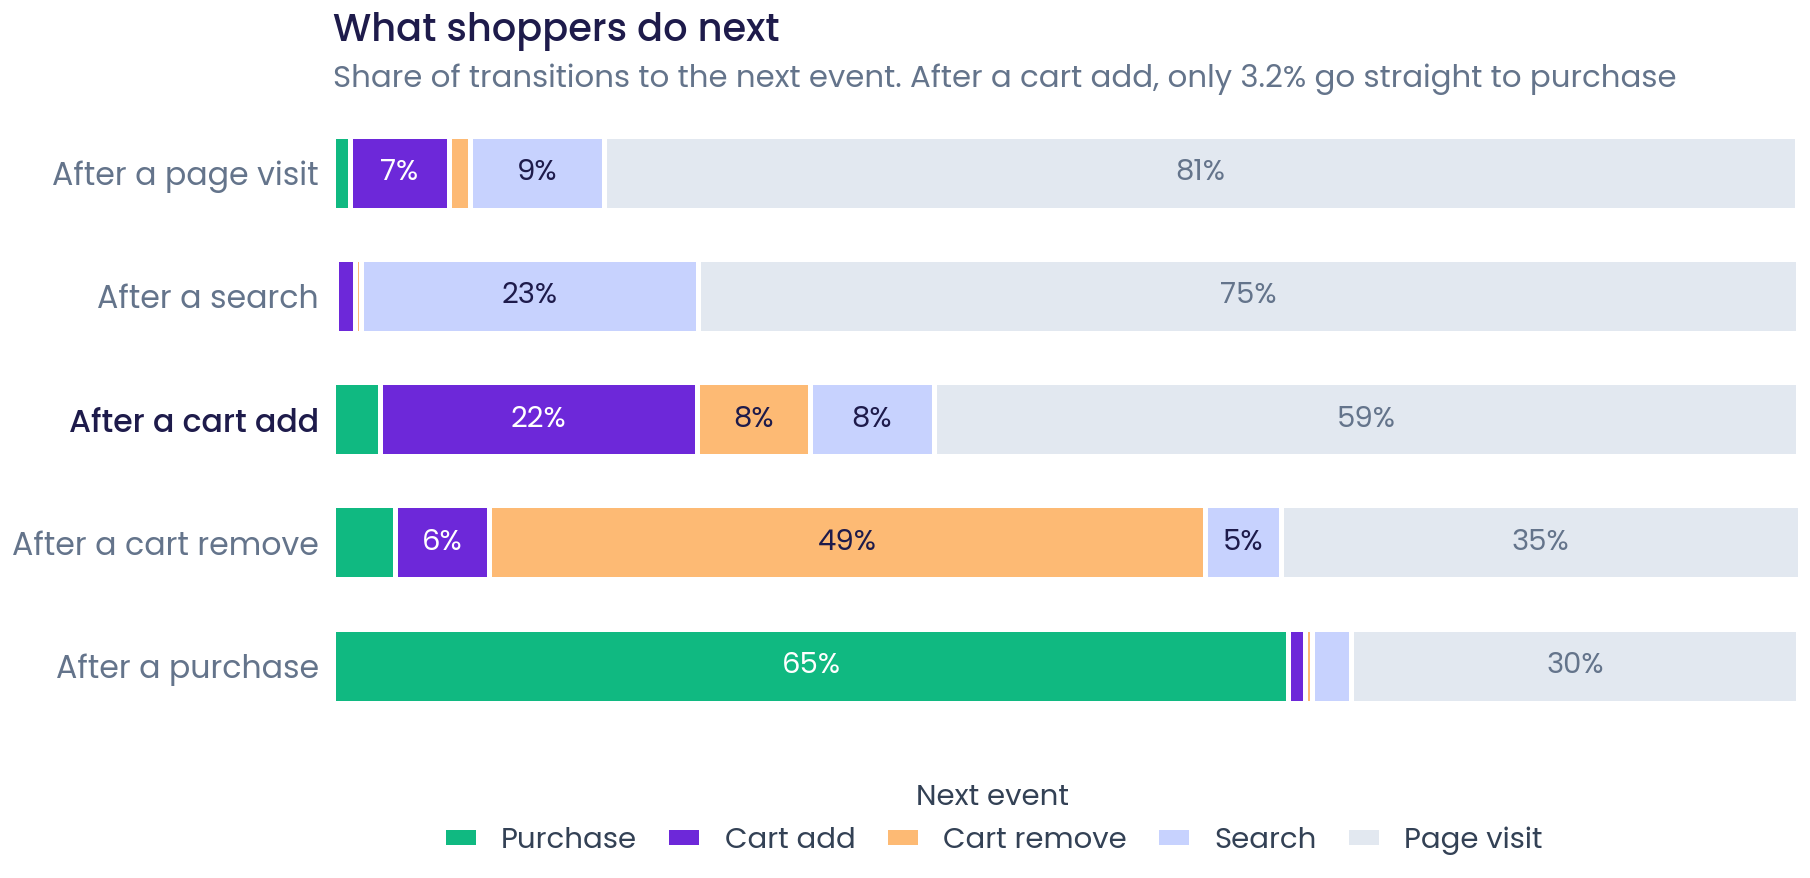

In [4]:
display(Image("outputs/figures/fig02_journey_transitions.png", width=750))

## 3. Cart abandonment (HEART: task success)

One row per (user, SKU) ever carted, de-duplicated **before** joining (a raw join fanned out rows ~7x in an earlier version).

In [5]:
q("""
SELECT COUNT(*) AS cart_items,
       ROUND(100*AVG(was_purchased::INT),1) AS purchased, ROUND(100*AVG(was_removed::INT),1) AS removed,
       ROUND(100*AVG(unresolved::INT),1) AS unresolved, ROUND(100*(1-AVG(was_purchased::INT)),1) AS abandonment
FROM cart_items
UNION ALL
SELECT COUNT(*), ROUND(100*AVG(was_purchased::INT),1), ROUND(100*AVG(was_removed::INT),1),
       ROUND(100*AVG(unresolved::INT),1), ROUND(100*(1-AVG(was_purchased::INT)),1)
FROM cart_items WHERE first_cart_ts < TIMESTAMP '2022-11-24'   -- censoring check: drop the last 14 days
""")

,cart_items,purchased,removed,unresolved,abandonment
0,450463,43.3,40.5,16.2,56.7
1,387979,43.8,41.7,14.5,56.2


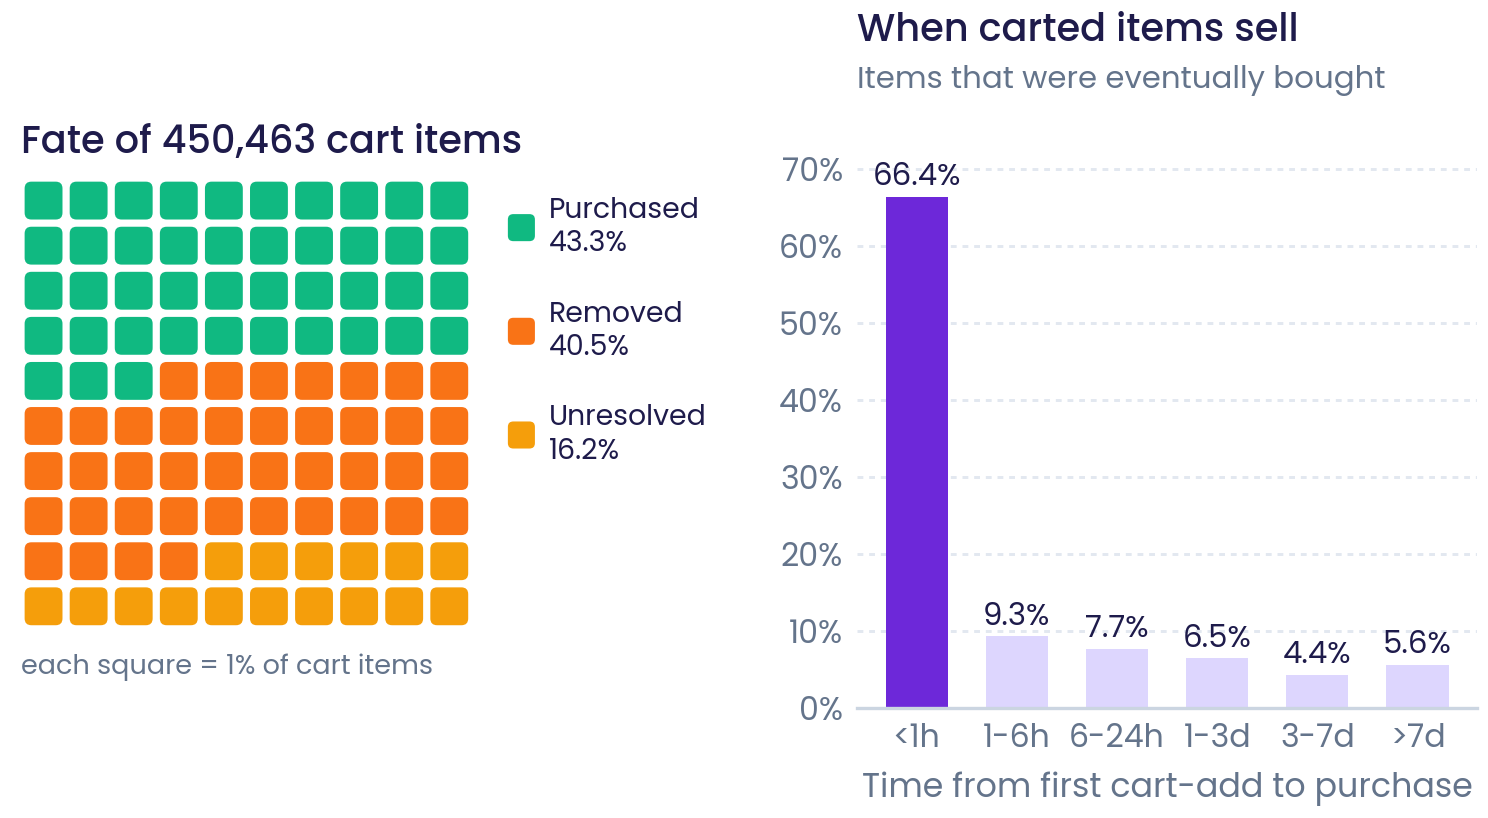

In [6]:
display(Image("outputs/figures/fig03_cart_outcomes.png", width=750))

## 4. Cohorts (HEART: retention)

In [7]:
coh = q("SELECT * FROM cohort_retention")
coh.pivot(index="cohort_month", columns="months_since_first", values="pct_retained")

months_since_first,0,1,2,3,4,5,6
cohort_month,,,,,,,
2022-06-01,100.0,40.7,34.5,33.0,33.6,33.3,14.5
2022-07-01,100.0,28.7,25.3,26.2,26.4,10.4,NaN
2022-08-01,100.0,24.7,23.5,23.4,8.8,NaN,NaN
2022-09-01,100.0,28.1,26.1,9.2,NaN,NaN,NaN
2022-10-01,100.0,28.5,9.1,NaN,NaN,NaN,NaN
2022-11-01,100.0,11.2,NaN,NaN,NaN,NaN,NaN
2022-12-01,100.0,NaN,NaN,NaN,NaN,NaN,NaN


Month-1 repeat purchase is 25–29% for the Jul–Oct cohorts, then flat. December has only 8 days of data. Abandonment by cohort stays between 52% and 59%, so it's not a new-customer problem.

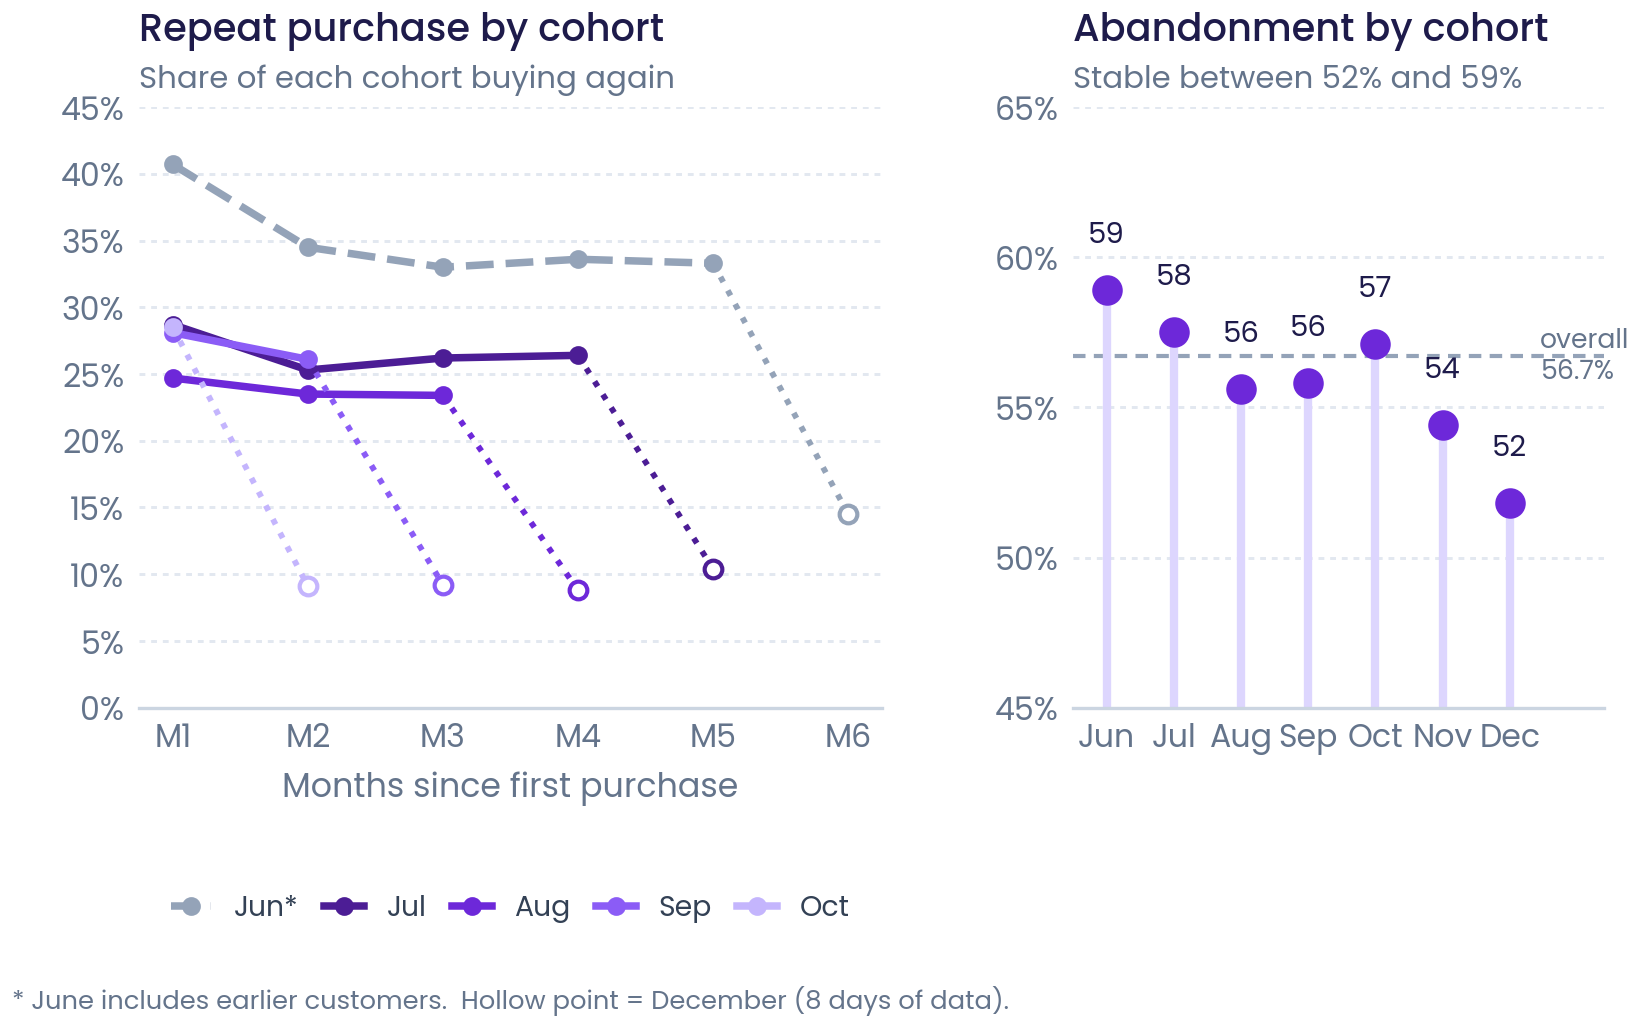

In [8]:
display(Image("outputs/figures/fig04_cohorts.png", width=750))

## 5. Who abandons: the headline Welch's t-test

In [9]:
us = q("SELECT u.*, COALESCE(s.sessions,0) AS sessions FROM user_segments u LEFT JOIN user_sessions s USING (client_id)")
hi, lo = us[us.abandon_segment == "high_abandon"], us[us.abandon_segment == "low_abandon"]
for m in ["searches", "visits"]:
    t, p = stats.ttest_ind(hi[m], lo[m], equal_var=False)
    print(f"{m:9s} high {hi[m].mean():6.1f}  low {lo[m].mean():5.1f}  ratio {hi[m].mean()/lo[m].mean():5.1f}x  Welch t = {t:.1f}, p = {p:.1e}")
us.groupby("abandon_segment").agg(users=("client_id","size"), searches=("searches","mean"), visits=("visits","mean"),
                                  never_carted_pct=("cart_adds", lambda x: 100*(x==0).mean()))

searches  high   39.7  low   2.1  ratio  18.9x  Welch t = 36.3, p = 3.9e-271
visits    high  276.8  low  26.7  ratio  10.4x  Welch t = 43.6, p = 0.0e+00


,users,searches,visits,never_carted_pct
abandon_segment,,,,
high_abandon,10280,39.69,276.84,0.0
low_abandon,24355,2.10,26.73,50.7
moderate_abandon,12038,38.51,278.81,0.0


**18.9x more searches.** But half the low-abandon group never used the cart (their removal rate defaults to 0), and moderate and high abandoners search almost identically. So the gap may mostly separate cart users from non-cart users.

## 6. Stress test: a like-for-like comparison

In [10]:
us["searches_per_session"] = us.searches / us.sessions.clip(lower=1)
c = us[us.cart_adds >= 3]
H, L = c[c.removal_rate >= 0.5], c[c.removal_rate < 0.2]
rows = []
for m in ["searches", "sessions", "cart_adds", "searches_per_session"]:
    t, p = stats.ttest_ind(H[m], L[m], equal_var=False); _, pu = stats.mannwhitneyu(H[m], L[m])
    rows.append((m, H[m].mean(), L[m].mean(), H[m].mean()/L[m].mean(), H[m].median(), L[m].median(), p, pu))
pd.DataFrame(rows, columns=["measure","high_mean","low_mean","ratio","high_median","low_median","welch_p","mann_whitney_p"])

,measure,high_mean,low_mean,ratio,high_median,low_median,welch_p,mann_whitney_p
0,searches,47.87,20.65,2.32,16.00,7.0,1.83e-83,5.17e-179
1,sessions,36.29,21.28,1.71,23.00,13.0,1.00e-142,1.58e-201
2,cart_adds,34.61,13.68,2.53,14.00,7.0,5.14e-137,0.00e+00
3,searches_per_session,1.36,1.28,1.07,0.75,0.5,4.68e-02,1.09e-43


Among comparable cart users the search gap is **2.3x** in total, but they also have 1.7x more sessions and 2.5x more cart-adds. Per session it's **1.07x** on average (median 0.75 vs 0.50). Heavy abandoners are mostly heavy users.

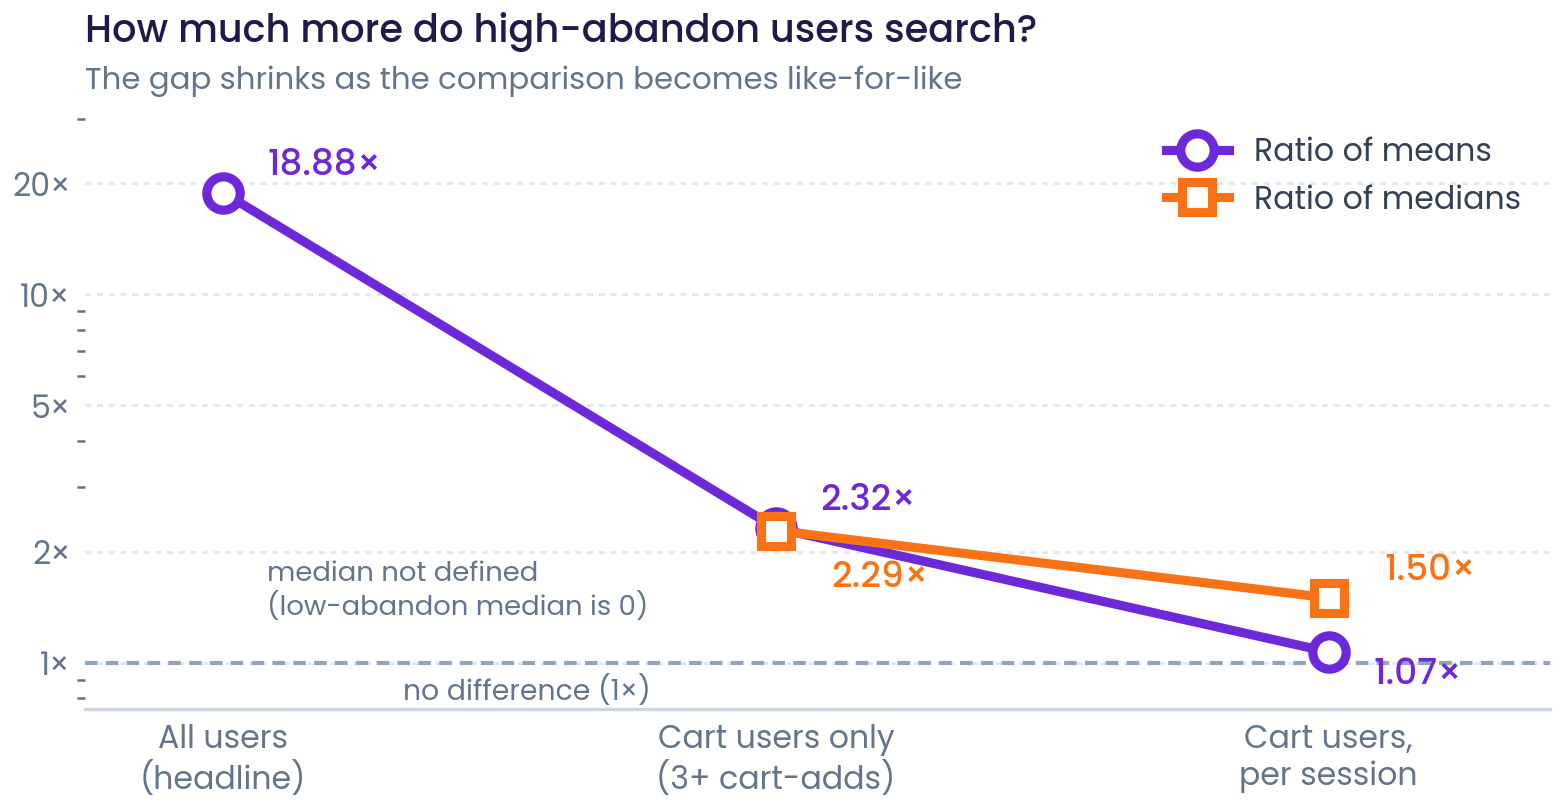

In [11]:
display(Image("outputs/figures/fig06_stress_test.png", width=700))

## 7. Direct test of comparison shopping

Was an abandoned item followed, within 7 days, by the same user buying a **different SKU from the same category**?

In [12]:
q("""
WITH ab AS (SELECT * FROM cart_items WHERE NOT was_purchased),
     buys AS (SELECT b.client_id, b.sku, b.ts, p.category FROM product_buy b JOIN product_properties p USING (sku))
SELECT COUNT(*) AS abandoned_items,
       ROUND(100*AVG(CASE WHEN EXISTS (SELECT 1 FROM buys x WHERE x.client_id=ab.client_id AND x.category=ab.category
             AND x.sku<>ab.sku AND x.ts BETWEEN ab.first_cart_ts AND ab.first_cart_ts + INTERVAL 7 DAY) THEN 1 ELSE 0 END),1)
       AS pct_replaced_same_category_7d
FROM ab
""")

,abandoned_items,pct_replaced_same_category_7d
0,255277,21.0


**About one abandoned item in five** was replaced by a same-category purchase within a week: the clearest evidence of comparison shopping.

## 8. Ruling out price; checking categories

In [13]:
print(q("""WITH t AS (SELECT *, NTILE(4) OVER (ORDER BY price_bucket) q FROM cart_items)
         SELECT q AS price_quartile, ROUND(100*AVG(was_purchased::INT),1) AS pct_purchased FROM t GROUP BY q ORDER BY q""").to_string(index=False))
print("corr(price, abandonment) =", round(q("SELECT CORR(price_bucket, 1 - was_purchased::INT) r FROM cart_items").r[0], 3))
q("SELECT COUNT(*) categories, MIN(abandonment_rate) min, QUANTILE_CONT(abandonment_rate,.25) p25, MEDIAN(abandonment_rate) median, QUANTILE_CONT(abandonment_rate,.75) p75, MAX(abandonment_rate) max FROM category_abandonment")

 price_quartile  pct_purchased
              1           45.3
              2           42.7
              3           43.0
              4           42.3
corr(price, abandonment) = 0.03


,categories,min,p25,median,p75,max
0,465,28.5,51.6,57.2,61.9,85.2


## 9. JTBD + RICE

In [14]:
R = json.load(open("outputs/results.json"))
pd.DataFrame(R["rice"])

,intervention,job_to_be_done,reach,impact,confidence,effort,rice_score
0,Comparison tool for heavy searchers,Help me compare options quickly so I can decid...,8,8,7,5,89.6
1,Reminders for items left in the cart,Remind me about items I was seriously considering,6,7,6,3,84.0
2,Better product info in high-abandon categories,Give me what I need to decide without leaving ...,5,8,6,6,40.0
3,Personalised recommendations before cart-add,Show me relevant options without extensive sea...,9,6,5,7,38.6


## Takeaways

1. **56.7%** of carted items are never bought (56.2% after the censoring check), stable across cohorts.
2. Carting sits inside a browsing loop: a cart-add is followed by a purchase only 3.2% of the time.
3. High-abandon users search **18.9x** more, but like-for-like it's **2.3x** in total and ~1.1–1.5x per session.
4. **21%** of abandoned items are replaced by a same-category purchase within 7 days: comparison shopping for about a fifth of abandonment.
5. Price is not the driver (r = 0.03).
6. Ship cart reminders first (cheap); A/B test a comparison tool for heavy cart users, judged on cart-to-purchase rate.